In [5]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC/Mescere/Kuru_Ladin/Kuru_Ladin_PointNet++/Kuru_Ladin_HDF5')

Mounted at /content/drive


In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# **1. HDF5 Veri Setini Yükleme ve Birleştirme**

def load_hdf5_data(h5_files):
    X_all, y_all = [], []
    for file in h5_files:
        with h5py.File(file, "r") as f:
            X = f["data"][:]
            y = f["labels"][:]
            X_all.append(X)
            y_all.append(y)
    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    return X_all, y_all

h5_files = ["ladin_dataset.h5", "kayın_dataset.h5", "kuru_ladin_dataset.h5"]
X_all, y_all = load_hdf5_data(h5_files)

print("Veri Seti Boyutu:", X_all.shape)
print("Etiket Seti Boyutu:", y_all.shape)

Veri Seti Boyutu: (233, 2048, 3)
Etiket Seti Boyutu: (233,)


In [23]:
# **📌 2. Veri Setini Eğitim (%70), Doğrulama (%15) ve Test (%15) Olarak Bölme**
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# **Boyutları Yazdırma**
print("Eğitim Seti Boyutu:", X_train.shape)
print("Doğrulama Seti Boyutu:", X_val.shape)
print("Test Seti Boyutu:", X_test.shape)


Eğitim Seti Boyutu: (163, 2048, 3)
Doğrulama Seti Boyutu: (35, 2048, 3)
Test Seti Boyutu: (35, 2048, 3)


In [9]:
# **3. PointNet Modeli Tanımlama (Keras & TensorFlow)**

def build_pointnet_model(num_classes=3, num_points=2048):
    inputs = keras.Input(shape=(num_points, 3))

    x = layers.Conv1D(64, 1, activation='relu')(inputs)
    x = layers.Conv1D(128, 1, activation='relu')(x)
    x = layers.Conv1D(256, 1, activation='relu')(x)

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="PointNet")
    return model

In [10]:
# **4. Modeli Derleme ve Eğitme**
model = build_pointnet_model(num_classes=3)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "PointNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 2048, 3)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 2048, 64)            │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 2048, 128)           │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 2048, 256)           │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 256)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,675 (549.51 KB)

 Trainable params: 140,675 (549.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# **5. Model Eğitimi**
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=8)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4009 - loss: 1.0286 - val_accuracy: 0.5143 - val_loss: 0.9235
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5280 - loss: 0.8968 - val_accuracy: 0.5143 - val_loss: 0.8434
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6165 - loss: 0.8012 - val_accuracy: 0.5429 - val_loss: 0.7582
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5154 - loss: 0.7453 - val_accuracy: 0.8286 - val_loss: 0.4905
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7548 - loss: 0.5544 - val_accuracy: 0.9429 - val_loss: 0.3628
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8043 - loss: 0.4859 - val_accuracy: 0.8857 - val_loss: 0.3310
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8124 - loss: 0.4523 - val_accuracy: 0.9143 - val_loss: 0.2827
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8401 - loss: 0.3593 - val_accuracy: 0.8286 - v

In [12]:
# **📌 6. Doğrulama Setinde Değerlendirme**
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f"\nDoğrulama Seti Doğruluğu: {val_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8042 - loss: 0.5386

Doğrulama Seti Doğruluğu: 0.8000


In [13]:
# **📌 7. Test Setinde Değerlendirme**
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Seti Doğruluğu: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8821 - loss: 0.3705

Test Seti Doğruluğu: 0.8857


In [14]:
# **📌 8. Doğrulama ve Test Setleri İçin Tahmin Yapma**
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [17]:
# **📌 9. Doğrulama ve Test Setleri İçin Performans Metrikleri**
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nDoğrulama Seti Performans Metrikleri:")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1 Score: {val_f1:.4f}")

print("\nTest Seti Performans Metrikleri:")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")


Doğrulama Seti Performans Metrikleri:
Precision: 0.8667
Recall: 0.8000
F1 Score: 0.7832

Test Seti Performans Metrikleri:
Precision: 0.9065
Recall: 0.8857
F1 Score: 0.8810


In [18]:
# **📌 10. Hata Matrisi Çizdirme**
def plot_confusion_matrix(y_true, y_pred, title):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_all), yticklabels=np.unique(y_all))
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(title)
    plt.show()

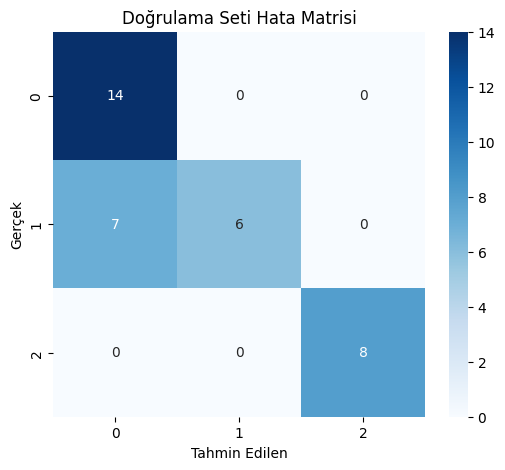

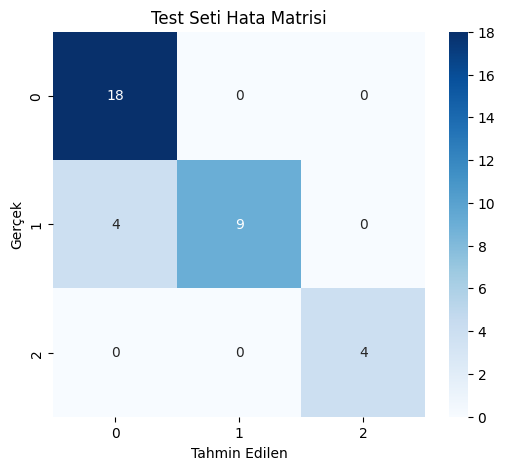

In [19]:
# **📌 11. Doğrulama ve Test İçin Hata Matrislerini Görselleştir**
plot_confusion_matrix(y_val, y_val_pred, "Doğrulama Seti Hata Matrisi")
plot_confusion_matrix(y_test, y_test_pred, "Test Seti Hata Matrisi")

In [26]:
# **📌 6. Performans Raporları (Doğrulama ve Test Setleri)**
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report (Validation Set):\n")
print(classification_report(y_val, y_val_pred, target_names=["Ladin", "Kayın", "Kuru Ladin"], digits=4))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred, target_names=["Ladin", "Kayın", "Kuru Ladin"], digits=4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Classification Report (Validation Set):

              precision    recall  f1-score   support

       Ladin     0.6667    1.0000    0.8000        14
       Kayın     1.0000    0.4615    0.6316        13
  Kuru Ladin     1.0000    1.0000    1.0000         8

    accuracy                         0.8000        35
   macro avg     0.8889    0.8205    0.8105        35
weighted avg     0.8667    0.8000    0.7832        35


Classification Report (Test Set):

              precision    recall  f1-score   support

       Ladin     0.8182    1.0000    0.9000        18
       Kayın     1.0000    0.6923    0.8182        13
  Kuru Ladin     1.0000    1.0000    1.0000         4

    accuracy                         0.8857        35
   macro avg     0.9394    0.8974    0.9061        35
weighted avg     0.9065    0.8857    0.8810        35



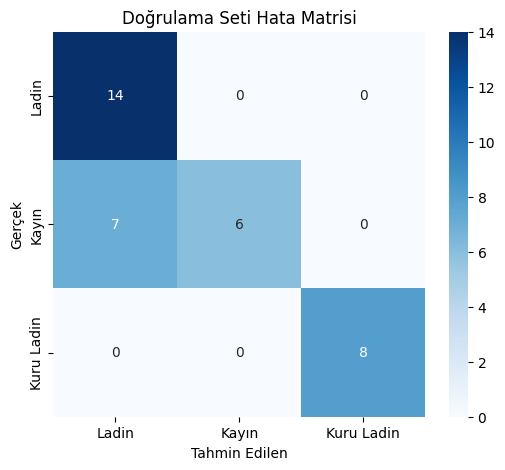

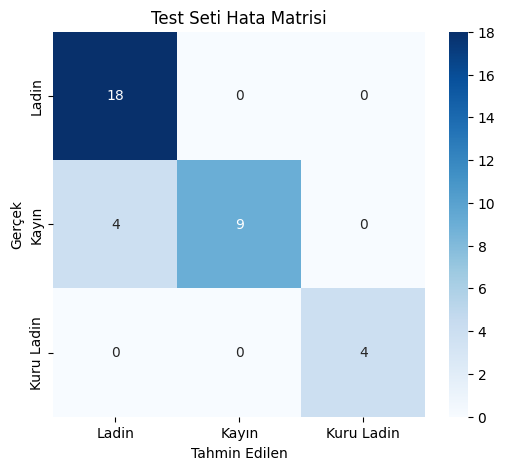

In [27]:
# **📌 7. Hata Matrisi Çizdirme**
def plot_confusion_matrix(y_true, y_pred, title):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Ladin", "Kayın", "Kuru Ladin"],
                yticklabels=["Ladin", "Kayın", "Kuru Ladin"])
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(title)
    plt.show()

# **📌 8. Doğrulama ve Test Setleri İçin Hata Matrislerini Görselleştir**
plot_confusion_matrix(y_val, y_val_pred, "Doğrulama Seti Hata Matrisi")
plot_confusion_matrix(y_test, y_test_pred, "Test Seti Hata Matrisi")

In [57]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Unin

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [6]:
# **1. HDF5 Veri Setini Yükleme ve Birleştirme**

def load_hdf5_data(h5_files):
    X_all, y_all = [], []
    for file in h5_files:
        with h5py.File(file, "r") as f:
            X = f["data"][:]
            y = f["labels"][:]
            X_all.append(X)
            y_all.append(y)
    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    return X_all, y_all

h5_files = ["ladin_dataset.h5", "kayın_dataset.h5", "kuru_ladin_dataset.h5"]
X_all, y_all = load_hdf5_data(h5_files)

print("Veri Seti Boyutu:", X_all.shape)
print("Etiket Seti Boyutu:", y_all.shape)

Veri Seti Boyutu: (233, 2048, 3)
Etiket Seti Boyutu: (233,)


In [7]:
# **📌 2. Veri Setini Eğitim (%70), Doğrulama (%15) ve Test (%15) Olarak Bölme**
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# **📌 3. PyTorch Veri Seti Oluşturma**
class PointCloudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = PointCloudDataset(X_train, y_train)
val_dataset = PointCloudDataset(X_val, y_val)
test_dataset = PointCloudDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [8]:
# **4. PointNet Model Tanımlaması**

class PointNet(nn.Module):
    def __init__(self, num_classes=3):
        super(PointNet, self).__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [9]:
# **5. Model Eğitimi**
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PointNet(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/50, Loss: 0.9922848116783869
Epoch 2/50, Loss: 0.9387351302873521
Epoch 3/50, Loss: 0.9004514870189485
Epoch 4/50, Loss: 0.852348438331059
Epoch 5/50, Loss: 0.8001092303366888
Epoch 6/50, Loss: 0.689177576984678
Epoch 7/50, Loss: 0.5823249050549099
Epoch 8/50, Loss: 0.5472363425152642
Epoch 9/50, Loss: 0.4425015470811299
Epoch 10/50, Loss: 0.4001088333981378
Epoch 11/50, Loss: 0.4334632129896255
Epoch 12/50, Loss: 0.4811853986410868
Epoch 13/50, Loss: 0.4010794961026737
Epoch 14/50, Loss: 0.36898166508901686
Epoch 15/50, Loss: 0.32961948145003545
Epoch 16/50, Loss: 0.28543307986997424
Epoch 17/50, Loss: 0.32831774918096407
Epoch 18/50, Loss: 0.3651692881470635
Epoch 19/50, Loss: 0.28546660641829175
Epoch 20/50, Loss: 0.2860052092444329
Epoch 21/50, Loss: 0.27457485525381
Epoch 22/50, Loss: 0.2715681369105975
Epoch 23/50, Loss: 0.3179012535228616
Epoch 24/50, Loss: 0.2916394874808334
Epoch 25/50, Loss: 0.2574574581923939
Epoch 26/50, Loss: 0.2773490927758671
Epoch 27/50, Loss: 0

In [10]:
# **6. Modeli Test Etme**
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
accuracy = correct / total
print(f"Test Doğruluğu: {accuracy * 100:.2f}%")

Test Doğruluğu: 85.71%


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score # Import necessary functions
import seaborn as sns
import matplotlib.pyplot as plt


Eğitim Seti Başarı Metrikleri:
Doğruluk: 0.9509
Kesinlik (Precision): 0.9514
Duyarlılık (Recall): 0.9509
F1 Skoru: 0.9508


Classification Report (Eğitim Set):

              precision    recall  f1-score   support

           0     0.9412    0.9639    0.9524        83
           1     0.9677    0.9231    0.9449        65
           2     0.9375    1.0000    0.9677        15

    accuracy                         0.9509       163
   macro avg     0.9488    0.9623    0.9550       163
weighted avg     0.9514    0.9509    0.9508       163



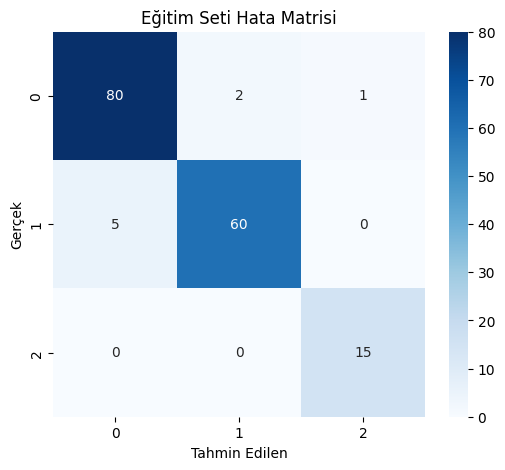


Doğrulama Seti Başarı Metrikleri:
Doğruluk: 0.8857
Kesinlik (Precision): 0.8857
Duyarlılık (Recall): 0.8857
F1 Skoru: 0.8857


Classification Report (Doğrulama Set):

              precision    recall  f1-score   support

           0     0.8571    0.8571    0.8571        14
           1     0.8462    0.8462    0.8462        13
           2     1.0000    1.0000    1.0000         8

    accuracy                         0.8857        35
   macro avg     0.9011    0.9011    0.9011        35
weighted avg     0.8857    0.8857    0.8857        35



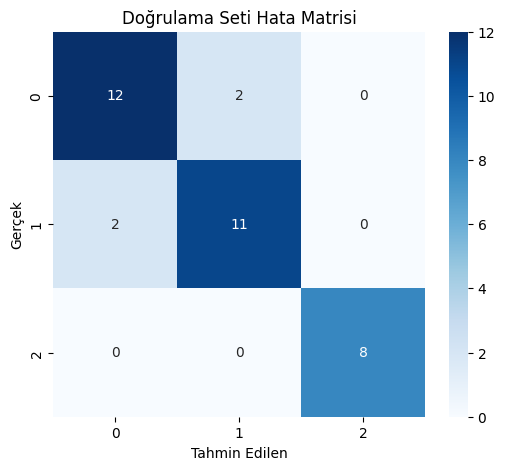


Test Seti Başarı Metrikleri:
Doğruluk: 0.8571
Kesinlik (Precision): 0.8595
Duyarlılık (Recall): 0.8571
F1 Skoru: 0.8567


Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.8824    0.8333    0.8571        18
           1     0.8462    0.8462    0.8462        13
           2     0.8000    1.0000    0.8889         4

    accuracy                         0.8571        35
   macro avg     0.8428    0.8932    0.8641        35
weighted avg     0.8595    0.8571    0.8567        35



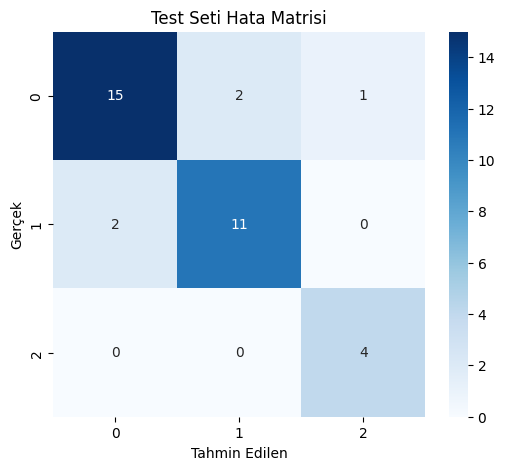

In [16]:
# **📌 4. Modelin Eğitim, Test ve Doğrulama Setlerinde Değerlendirilmesi**
def evaluate_model(model, data_loader, dataset_name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{dataset_name} Seti Başarı Metrikleri:")
    print(f"Doğruluk: {acc:.4f}")
    print(f"Kesinlik (Precision): {precision:.4f}")
    print(f"Duyarlılık (Recall): {recall:.4f}")
    print(f"F1 Skoru: {f1:.4f}\n")

    print(f"\nClassification Report ({dataset_name} Set):\n")
    print(classification_report(y_true, y_pred, digits=4))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(f"{dataset_name} Seti Hata Matrisi")
    plt.show()

# **📌 5. Modelin Eğitim, Test ve Doğrulama Setlerinde Performansını Hesapla**
evaluate_model(model, train_loader, "Eğitim")
evaluate_model(model, val_loader, "Doğrulama")
evaluate_model(model, test_loader, "Test")


In [17]:
# **4. Model Tanımlamaları**

class PointNetPlusPlus(PointNet):
    def __init__(self, num_classes=3):
        super(PointNetPlusPlus, self).__init__(num_classes)
        self.conv4 = nn.Conv1d(256, 512, 1)
        self.pool = nn.AdaptiveMaxPool1d(1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

In [18]:
# **5. Model Eğitimi**
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PointNet(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/50, Loss: 0.9440995965685163
Epoch 2/50, Loss: 0.9437540542511713
Epoch 3/50, Loss: 0.9138068187804449
Epoch 4/50, Loss: 0.8678909029279437
Epoch 5/50, Loss: 0.8206205509957814
Epoch 6/50, Loss: 0.7749165963558924
Epoch 7/50, Loss: 0.7384218729677654
Epoch 8/50, Loss: 0.5797258076213655
Epoch 9/50, Loss: 0.5739466427337556
Epoch 10/50, Loss: 0.4620054648036048
Epoch 11/50, Loss: 0.5230554008767718
Epoch 12/50, Loss: 0.38836830641542164
Epoch 13/50, Loss: 0.33685876961265293
Epoch 14/50, Loss: 0.3883646641458784
Epoch 15/50, Loss: 0.3318543662982328
Epoch 16/50, Loss: 0.32437190289298695
Epoch 17/50, Loss: 0.34365841728590785
Epoch 18/50, Loss: 0.32632123962754295
Epoch 19/50, Loss: 0.3183083434899648
Epoch 20/50, Loss: 0.31139334042867023
Epoch 21/50, Loss: 0.321170208354791
Epoch 22/50, Loss: 0.39165198678771657
Epoch 23/50, Loss: 0.3720844327693894
Epoch 24/50, Loss: 0.27773809078193845
Epoch 25/50, Loss: 0.28831169860703604
Epoch 26/50, Loss: 0.2513239867098275
Epoch 27/50, 

In [19]:
# **6. Modeli Test Etme**
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
accuracy = correct / total
print(f"Test Doğruluğu: {accuracy * 100:.2f}%")

Test Doğruluğu: 94.29%



Eğitim Seti Başarı Metrikleri:
Doğruluk: 0.9571
Kesinlik (Precision): 0.9571
Duyarlılık (Recall): 0.9571
F1 Skoru: 0.9570


Classification Report (Eğitim Set):

              precision    recall  f1-score   support

           0     0.9524    0.9639    0.9581        83
           1     0.9531    0.9385    0.9457        65
           2     1.0000    1.0000    1.0000        15

    accuracy                         0.9571       163
   macro avg     0.9685    0.9674    0.9679       163
weighted avg     0.9571    0.9571    0.9570       163



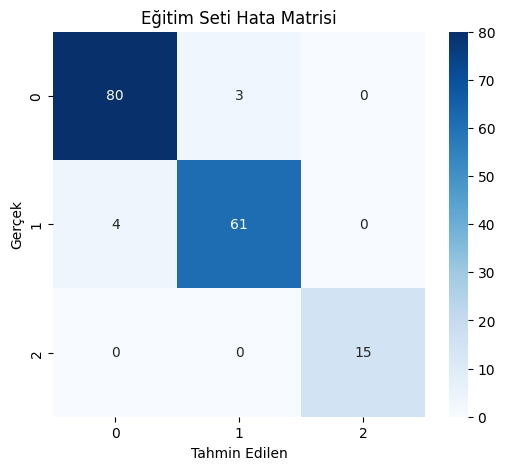


Doğrulama Seti Başarı Metrikleri:
Doğruluk: 0.8857
Kesinlik (Precision): 0.8940
Duyarlılık (Recall): 0.8857
F1 Skoru: 0.8869


Classification Report (Doğrulama Set):

              precision    recall  f1-score   support

           0     0.8125    0.9286    0.8667        14
           1     0.9167    0.8462    0.8800        13
           2     1.0000    0.8750    0.9333         8

    accuracy                         0.8857        35
   macro avg     0.9097    0.8832    0.8933        35
weighted avg     0.8940    0.8857    0.8869        35



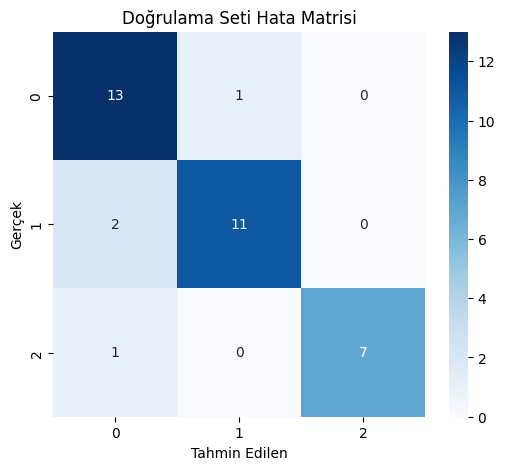


Test Seti Başarı Metrikleri:
Doğruluk: 0.9429
Kesinlik (Precision): 0.9429
Duyarlılık (Recall): 0.9429
F1 Skoru: 0.9429


Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.9444    0.9444    0.9444        18
           1     0.9231    0.9231    0.9231        13
           2     1.0000    1.0000    1.0000         4

    accuracy                         0.9429        35
   macro avg     0.9558    0.9558    0.9558        35
weighted avg     0.9429    0.9429    0.9429        35



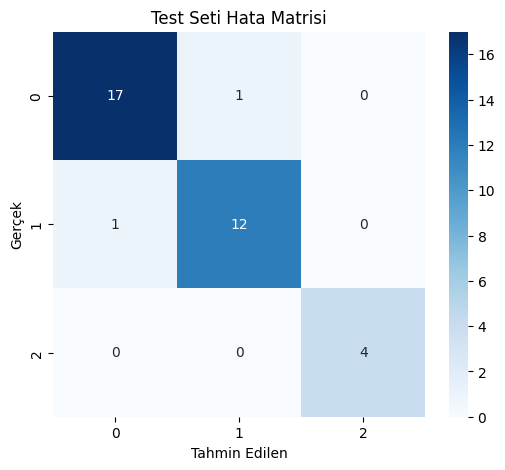

In [20]:
# **📌 4. Modelin Eğitim, Test ve Doğrulama Setlerinde Değerlendirilmesi**
def evaluate_model(model, data_loader, dataset_name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{dataset_name} Seti Başarı Metrikleri:")
    print(f"Doğruluk: {acc:.4f}")
    print(f"Kesinlik (Precision): {precision:.4f}")
    print(f"Duyarlılık (Recall): {recall:.4f}")
    print(f"F1 Skoru: {f1:.4f}\n")

    print(f"\nClassification Report ({dataset_name} Set):\n")
    print(classification_report(y_true, y_pred, digits=4))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(f"{dataset_name} Seti Hata Matrisi")
    plt.show()

# **📌 5. Modelin Eğitim, Test ve Doğrulama Setlerinde Performansını Hesapla**
evaluate_model(model, train_loader, "Eğitim")
evaluate_model(model, val_loader, "Doğrulama")
evaluate_model(model, test_loader, "Test")


In [21]:
# **📌 4. DGCNN Modeli**
class DGCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(DGCNN, self).__init__()
        self.conv1 = nn.Conv1d(3, 64, kernel_size=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=1)
        self.conv4 = nn.Conv1d(256, 512, kernel_size=1)
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.global_pool(x).squeeze(-1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [22]:
# **📌 5. Modeli Eğitme**
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DGCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}, Accuracy: {train_acc:.4f}")

Epoch 1/50, Loss: 0.9987, Accuracy: 0.4356
Epoch 2/50, Loss: 0.9421, Accuracy: 0.5092
Epoch 3/50, Loss: 0.9174, Accuracy: 0.5153
Epoch 4/50, Loss: 0.8661, Accuracy: 0.5460
Epoch 5/50, Loss: 0.8324, Accuracy: 0.6012
Epoch 6/50, Loss: 0.7719, Accuracy: 0.6564
Epoch 7/50, Loss: 0.7133, Accuracy: 0.6135
Epoch 8/50, Loss: 0.7482, Accuracy: 0.6319
Epoch 9/50, Loss: 0.6455, Accuracy: 0.6871
Epoch 10/50, Loss: 0.6205, Accuracy: 0.7178
Epoch 11/50, Loss: 0.4772, Accuracy: 0.8221
Epoch 12/50, Loss: 0.4573, Accuracy: 0.8405
Epoch 13/50, Loss: 0.3625, Accuracy: 0.8528
Epoch 14/50, Loss: 0.3622, Accuracy: 0.8773
Epoch 15/50, Loss: 0.5898, Accuracy: 0.7914
Epoch 16/50, Loss: 0.5081, Accuracy: 0.7914
Epoch 17/50, Loss: 0.3650, Accuracy: 0.8773
Epoch 18/50, Loss: 0.3143, Accuracy: 0.8712
Epoch 19/50, Loss: 0.2938, Accuracy: 0.8896
Epoch 20/50, Loss: 0.3124, Accuracy: 0.8528
Epoch 21/50, Loss: 0.2814, Accuracy: 0.8834
Epoch 22/50, Loss: 0.2692, Accuracy: 0.8896
Epoch 23/50, Loss: 0.2567, Accuracy: 0.89

In [23]:
# **6. Modeli Test Etme**
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
accuracy = correct / total
print(f"Test Doğruluğu: {accuracy * 100:.2f}%")

Test Doğruluğu: 88.57%



Classification Report (Eğitim Set):

              precision    recall  f1-score   support

           0     0.9432    1.0000    0.9708        83
           1     1.0000    0.9231    0.9600        65
           2     1.0000    1.0000    1.0000        15

    accuracy                         0.9693       163
   macro avg     0.9811    0.9744    0.9769       163
weighted avg     0.9711    0.9693    0.9692       163



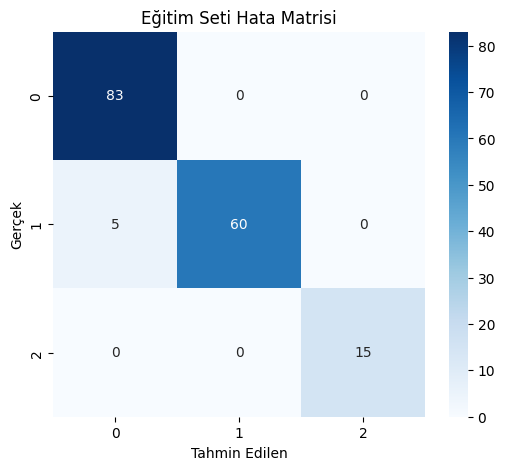


Classification Report (Doğrulama Set):

              precision    recall  f1-score   support

           0     0.8125    0.9286    0.8667        14
           1     0.9091    0.7692    0.8333        13
           2     1.0000    1.0000    1.0000         8

    accuracy                         0.8857        35
   macro avg     0.9072    0.8993    0.9000        35
weighted avg     0.8912    0.8857    0.8848        35



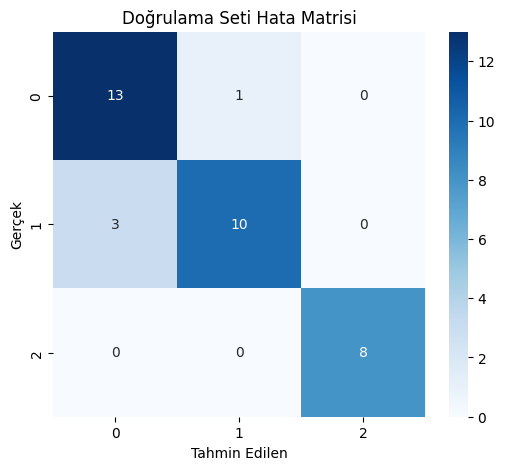


Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.9375    0.8333    0.8824        18
           1     0.8571    0.9231    0.8889        13
           2     0.8000    1.0000    0.8889         4

    accuracy                         0.8857        35
   macro avg     0.8649    0.9188    0.8867        35
weighted avg     0.8919    0.8857    0.8855        35



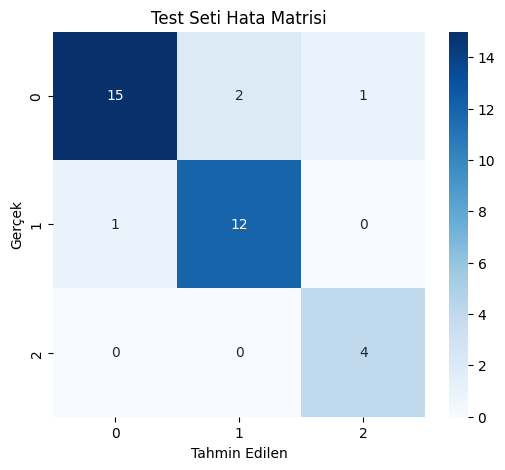

In [24]:
# **📌 6. Modelin Eğitim, Test ve Doğrulama Setlerinde Performansını Hesapla**
def evaluate_model(model, data_loader, dataset_name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch.to(device))
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds)

    print(f"\nClassification Report ({dataset_name} Set):\n")
    print(classification_report(y_true, y_pred, digits=4))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(f"{dataset_name} Seti Hata Matrisi")
    plt.show()

evaluate_model(model, train_loader, "Eğitim")
evaluate_model(model, val_loader, "Doğrulama")
evaluate_model(model, test_loader, "Test")